## **Installing the Necessary Libraries**

- We begin by installing the required libraries needed for this project.
In particular, we will use the YOLO (You Only Look Once) object detection model,
which will be trained on our dataset for accurate object detection.

In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from roboflow import Roboflow
import json

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Importing the Dataset from Roboflow


In [5]:
from google.colab import userdata

rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
project = rf.workspace(userdata.get('ROBOFLOW_WORKSPACE')).project("labeled-mri-brain-tumor-dataset-hie10")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Labeled-MRI-Brain-Tumor-Dataset-1 in yolov11:: 100%|██████████| 11671/11671 [00:01<00:00, 6306.55it/s]


## Data Visualization

In this section, we visualize the dataset and explore sample images
to better understand the data before training the YOLO model.

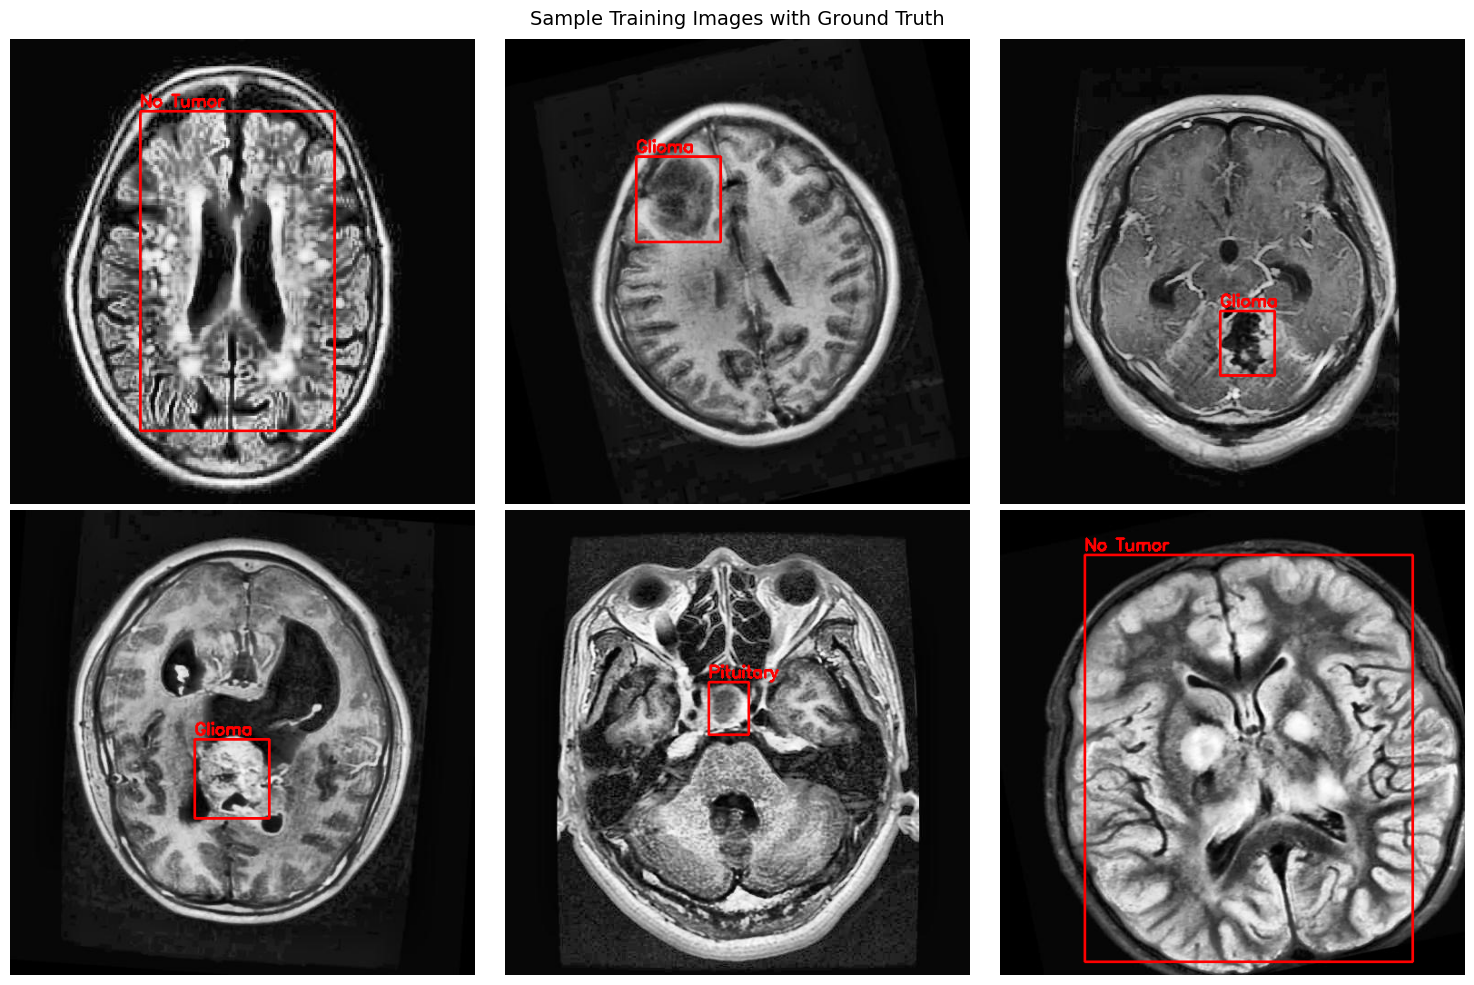

In [10]:

import cv2, random, os, yaml

with open("/content/Labeled-MRI-Brain-Tumor-Dataset-1/data.yaml", "r") as f:
    data_config = yaml.safe_load(f)
class_names = data_config['names']

sample_imgs = random.sample(os.listdir("/content/Labeled-MRI-Brain-Tumor-Dataset-1/train/images"), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, img_name in enumerate(sample_imgs):
    img_path = f"/content/Labeled-MRI-Brain-Tumor-Dataset-1/train/images/{img_name}"
    lbl_path = f"/content/Labeled-MRI-Brain-Tumor-Dataset-1/train/labels/{img_name.replace('.jpg','.txt').replace('.png','.txt')}"

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
                cv2.putText(img, class_names[cls], (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

    axes[i].imshow(img)
    axes[i].axis("off")

plt.suptitle("Sample Training Images with Ground Truth", fontsize=14)
plt.tight_layout()
plt.show()

##  Loading & Traning the Pretrained YOLO Model

In [11]:
model = YOLO('/content/yolo11s.pt')

results = model.train(
    data=r"/content/Labeled-MRI-Brain-Tumor-Dataset-1/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="brain_tumor_yolo11s",
    patience=10,
    lr0=0.01,
    lrf=0.001,
    weight_decay=0.0005,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    flipud=0.3,
    fliplr=0.5,
    mosaic=1.0,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    save=True,
    plots=True,
    verbose=True
)

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Labeled-MRI-Brain-Tumor-Dataset-1/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor_yolo11s, nbs=64, nms=False, opset=None, optimize=False, 

In [12]:
from google.colab import files
files.download(f"/content/runs/detect/brain_tumor_yolo11s/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model Evaluation

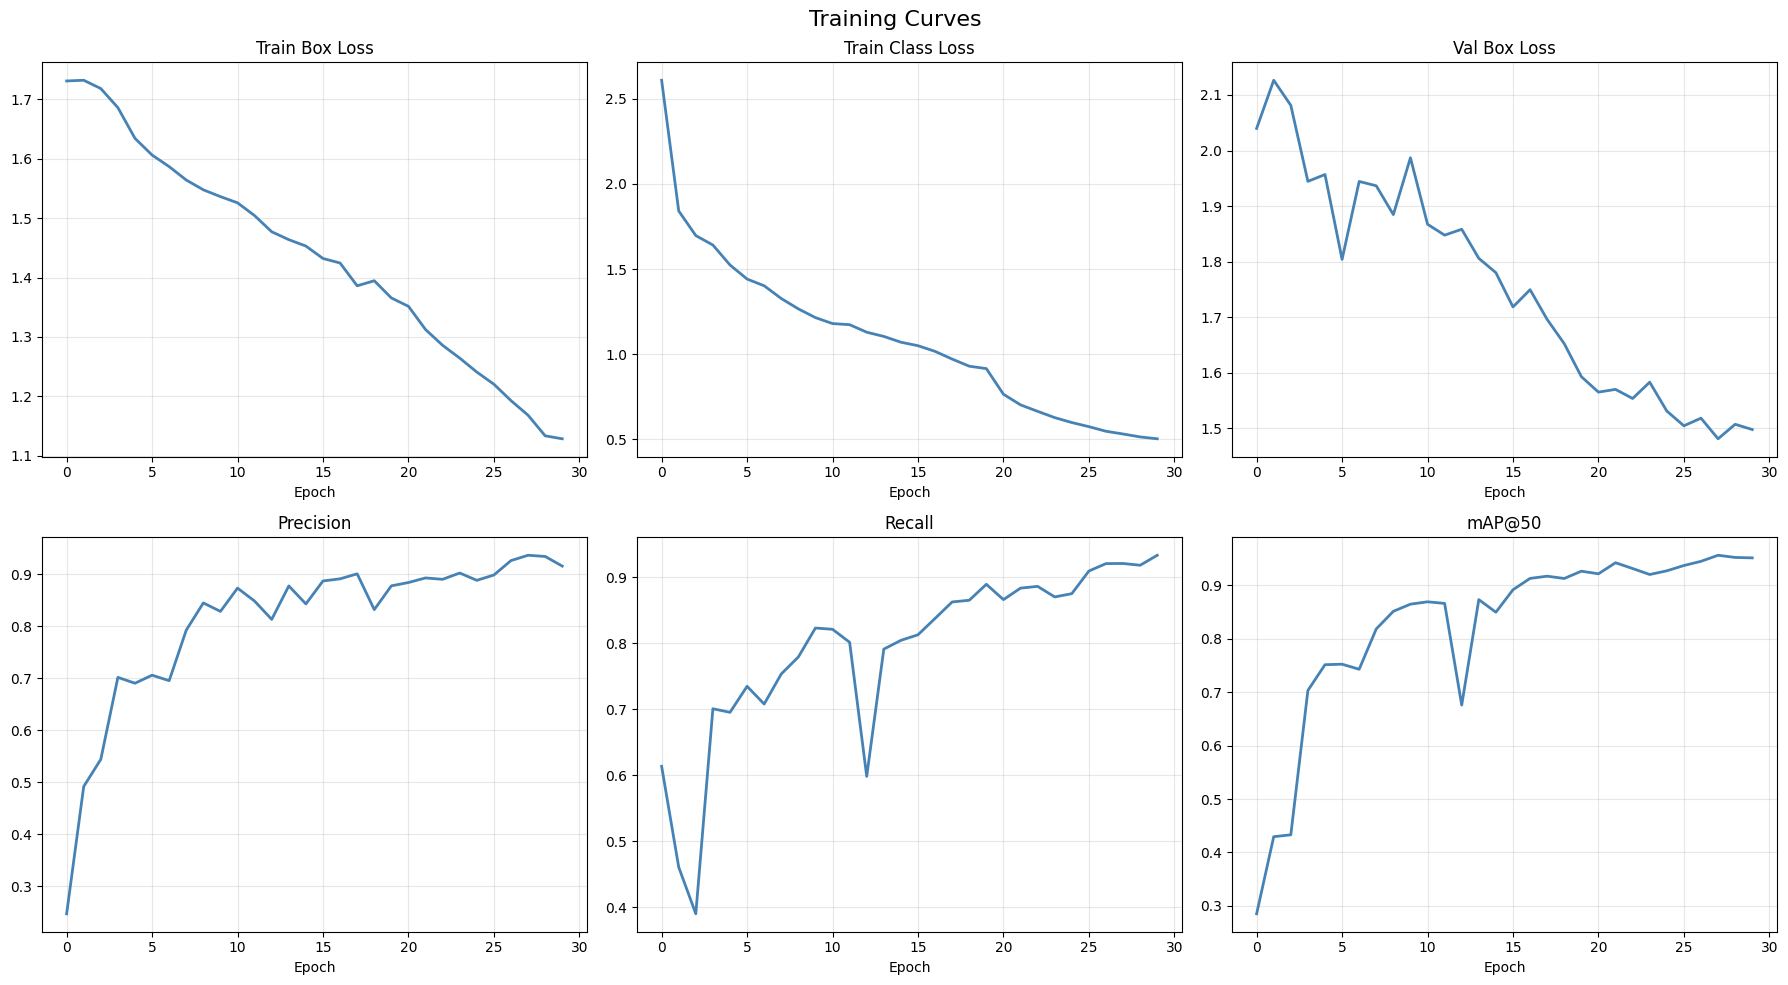

In [13]:
## Training Curves Visualization

import pandas as pd

results_csv = f"/content/runs/detect/brain_tumor_yolo11s/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = [
    ('train/box_loss', 'Train Box Loss'),
    ('train/cls_loss', 'Train Class Loss'),
    ('val/box_loss',   'Val Box Loss'),
    ('metrics/precision(B)', 'Precision'),
    ('metrics/recall(B)',    'Recall'),
    ('metrics/mAP50(B)',     'mAP@50'),
]

for ax, (col, title) in zip(axes.flatten(), metrics_to_plot):
    if col in df.columns:
        ax.plot(df[col], color='steelblue', linewidth=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)

plt.suptitle("Training Curves", fontsize=16)
plt.tight_layout()
plt.show()

## Predicting on Test Images


image 1/1 /content/Labeled-MRI-Brain-Tumor-Dataset-1/test/images/Tr-gl_0126_jpg.rf.97ab16efa7ecd793760c3e0716412cee.jpg: 640x640 1 Glioma, 15.5ms
Speed: 3.7ms preprocess, 15.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
1 label saved to /content/runs/detect/predict/labels


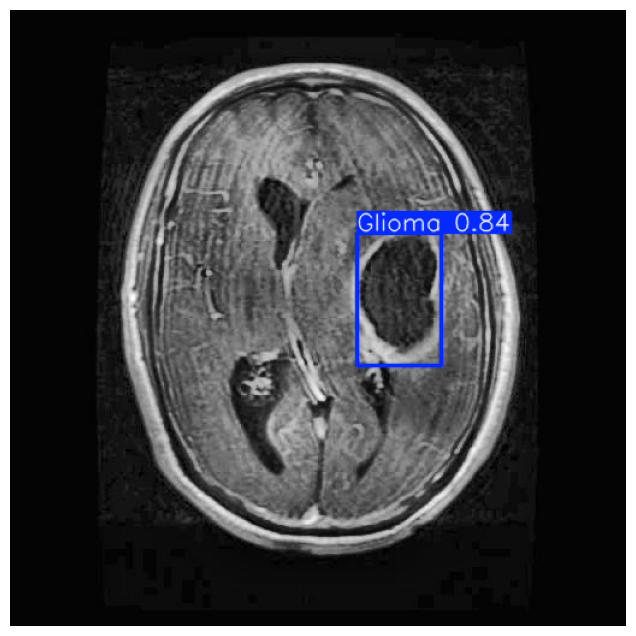

In [14]:
import cv2
import matplotlib.pyplot as plt

result = model.predict(
    source="/content/Labeled-MRI-Brain-Tumor-Dataset-1/test/images/Tr-gl_0126_jpg.rf.97ab16efa7ecd793760c3e0716412cee.jpg",
    conf=0.6,
    iou=0.45,
    save=True,
    save_txt=True
)

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(result[0].plot(), cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()